# Notebook 06 — RQ5: MRRS Composite Scoring Tool
## Evaluating AI/ML Credit Risk Models in U.S. Mortgage Lending

**Capstone:** QM640 Data Analytics Capstone — Walsh College  
**Author:** Saroj Kumar Nanda  
**Mentor:** Keya Choudhury Ganguli  
**Term:** Winter 2025  
**GitHub:** https://github.com/sarojnanda1/capstone

**Depends on:**
- `reports/rq1_metrics.json`
- `reports/rq2_metrics.json`
- `reports/rq3_metrics.json`
- `reports/rq4_metrics.json`
---

## Environment Note
This notebook was developed in Google Colab with data stored in Google Drive.  
File paths reference `/content/drive/MyDrive/capstone/...` and will need to be  
updated for local execution. All four dependency JSON files are noted in the  
*Depends on* section above.

---

## Research Question 5
*Can a composite MRRS, aggregating performance, fairness, explainability, and stability metrics, reliably rank credit risk models by regulatory readiness, and does the ranking align with SR 11-7 compliance expectations?*

---

## MRRS Formula
**MRRS = Σ wᵢ × NormalizedScoreᵢ**

## Model Evaluation Framework

| Dimension              | Weight | Source | Rationale                                      | Key Metrics |
|----------------------|--------|--------|-----------------------------------------------|------------|
| Predictive Performance | 0.35   | RQ1    | Primary purpose of a credit model             | AUC, Gini, KS |
| Fairness              | 0.30   | RQ2    | Regulatory non-negotiable (ECOA)              | Disparate Impact Ratio (DIR), Equalized Odds, Pricing fairness |
| Explainability        | 0.20   | RQ3    | SR 11-7 documentation requirements            | SHAP stability (Spearman ρ), feature importance consistency |
| Temporal Stability    | 0.15   | RQ4    | Ongoing monitoring requirement                | Population Stability Index (PSI - inverted), drift metrics |


---

## Notebook Structure
| Cell | Description |
|---|---|
| Cell 0 | Imports, Drive mount, paths |
| Cell 1 | Load RQ1–RQ4 metric JSONs |
| Cell 2 | SR 11-7 weights and formula |
| Cell 3 | Extract and normalise raw metrics |
| Cell 4 | Compute MRRS and rank models |
| Cell 5 | Sensitivity analysis (±10% weight perturbation) |
| Cell 6 |  |
| Cell 7 | Figures 25–28 |
| Cell 8 | Save results |
| Cell 9 | Final readiness verdict and project summary |

---

## Outputs Produced
| File | Description |
|---|---|
| `fig25_mrrs_radar.png` | Radar chart of dimension scores |
| `fig26_mrrs_stacked.png` | Stacked bar of MRRS contributions |
| `fig27_mrrs_heatmap.png` | Heatmap of all scores |
| `fig28_mrrs_sensitivity.png` | Sensitivity analysis plot |
| `table5_mrrs_scores.csv` | Final MRRS table for interim report |
| `mrrs_results.json` | Complete MRRS output |
| `rq5_mrrs_report.txt` | Full text report |

In [ ]:
"""
CELL 0 — Environment Initialization, Paths, Logging Utilities
=============================================================

Purpose
-------
Initializes the runtime environment for the RQ5 MRRS (Model Risk Review
System) analysis pipeline. This cell configures imports, reproducibility
seeds, directory paths, logging utilities, and global styling for plots.

This cell is intentionally lightweight and side‑effect‑driven, as it
prepares the notebook environment for all downstream cells.

Key Components
--------------
1. Imports
   - Core scientific stack: NumPy, pandas, SciPy, matplotlib, seaborn
   - File I/O: os, json
   - Colab Drive mounting for persistent storage
   - Statistical utilities: spearmanr

2. Reproducibility
   - Sets global seeds for NumPy and Python's `random` module.

3. Directory Setup
   - Defines base project paths.
   - Ensures report and figure directories exist.

4. Logging Utilities
   - `log(msg)`: prints and stores messages for report export.
   - `section(title)`: formatted section header.
   - `subsection(title)`: formatted subsection header.

5. Plotting Theme
   - Applies a consistent seaborn theme for all figures.

Outputs
-------
- Mounted Google Drive
- Initialized global variables:
    BASE, REPORT_DIR, FIG_DIR, REPORT_FILE, report_lines
- Logging helper functions available globally
- Confirmation message: "✓ Cell 0 complete"
"""

# CELL 0 · Imports, Drive mount, seeds, paths
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# ── Paths ────────────────────────────────────────────────────────────────────
BASE        = "/content/drive/MyDrive/capstone"
REPORT_DIR  = f"{BASE}/reports"
FIG_DIR     = f"{BASE}/reports/figures"
REPORT_FILE = f"{REPORT_DIR}/rq5_mrrs_report.txt"

for d in [REPORT_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Logging Utilities ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
report_lines = []

def log(msg=""):
    """
    Append a message to the global report log and print it.

    Parameters
    ----------
    msg : str, optional
        Message to print and store. Defaults to an empty string.

    Notes
    -----
    - All messages are appended to `report_lines` for later export.
    - Used throughout the notebook for consistent logging.
    """
    print(msg)
    report_lines.append(str(msg))


def section(title):
    """
    Print a formatted section header and log it.

    Parameters
    ----------
    title : str
        Title of the section.

    Notes
    -----
    Produces a visually distinct header block for readability in both
    notebook output and exported text reports.
    """
    bar = "=" * 70
    log(); log(bar); log(f"  {title}"); log(bar)


def subsection(title):
    """
    Print a formatted subsection header and log it.

    Parameters
    ----------
    title : str
        Title of the subsection.

    Notes
    -----
    Produces a lighter-weight header than `section()`, used for
    structuring subsections within a cell.
    """
    log(); log(f"── {title} " + "─" * max(0, 58 - len(title)))


print("✓ Cell 0 complete")


Mounted at /content/drive
✓ Cell 0 complete


In [ ]:
"""
CELL 1 — Load Metric Outputs from RQ1–RQ4
=========================================

Purpose
-------
Loads the JSON metric artifacts produced by prior notebooks (RQ1–RQ4).
These files contain the finalized model‑level metrics for Logistic
Regression, XGBoost, and FNN across the MRRS dimensions:

- RQ1: Model performance and statistical tests
- RQ2: Fairness metrics and pricing discrimination analysis
- RQ3: SHAP interpretability and stability metrics
- RQ4: Drift diagnostics (PSI, KL, AUC trends)

This cell validates that all required artifacts exist before continuing
to the RQ5 MRRS composite scoring workflow.

Workflow
--------
1. Define a helper function `load_json()` for safe JSON loading with
   logging and missing‑file handling.
2. Load the four metric JSON files from `REPORT_DIR`.
3. Validate that all files are present; raise an error if any are missing.
4. Define canonical model keys and human‑readable labels.

Inputs
------
- JSON files located in:
    {REPORT_DIR}/rq1_metrics.json
    {REPORT_DIR}/rq2_metrics.json
    {REPORT_DIR}/rq3_metrics.json
    {REPORT_DIR}/rq4_metrics.json

Outputs
-------
- `rq1`, `rq2`, `rq3`, `rq4` : dict
    Parsed JSON dictionaries containing model metrics.
- `MODELS` : list[str]
    Canonical model identifiers: ["lr", "xgb", "fnn"].
- `MODEL_LABELS` : dict
    Mapping from canonical keys to human‑readable model names.

Raises
------
FileNotFoundError
    If any of the four required JSON files are missing.

Notes
-----
This cell is a hard dependency for all downstream RQ5 computations.
"""

# CELL 1 · Load metric outputs from all prior notebooks
# =============================================================================
section("CELL 1 · Load metric outputs from RQ1–RQ4")

log("""
  Loading JSON metric files produced by notebooks 02–05.
  Each file contains the raw metric values for LR, XGBoost, and FNN
  across the four MRRS dimensions.
""")

def load_json(path, name):
    """
    Load a JSON file from disk with logging and missing‑file handling.

    Parameters
    ----------
    path : str
        Full file path to the JSON file.
    name : str
        Human‑readable name used in log messages.

    Returns
    -------
    dict or None
        Parsed JSON dictionary if the file exists; otherwise None.

    Notes
    -----
    - Logs success or failure using the global `log()` function.
    - Used for loading RQ1–RQ4 metric artifacts.
    """
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        log(f"  ✓ {name} loaded: {path}")
        return data
    else:
        log(f"  ✗ {name} NOT FOUND: {path}")
        return None


# ── Load RQ1–RQ4 metric artifacts ────────────────────────────────────────────
rq1 = load_json(f"{REPORT_DIR}/rq1_metrics.json", "RQ1 metrics")
rq2 = load_json(f"{REPORT_DIR}/rq2_metrics.json", "RQ2 metrics")
rq3 = load_json(f"{REPORT_DIR}/rq3_metrics.json", "RQ3 metrics")
rq4 = load_json(f"{REPORT_DIR}/rq4_metrics.json", "RQ4 metrics")

if any(m is None for m in [rq1, rq2, rq3, rq4]):
    raise FileNotFoundError(
        "One or more metric JSON files not found. "
        "Ensure notebooks 02–05 have completed successfully."
    )

# ── Model keys and labels ────────────────────────────────────────────────────
MODELS = ["lr", "xgb", "fnn"]
MODEL_LABELS = {
    "lr":  "Logistic Regression",
    "xgb": "XGBoost",
    "fnn": "FNN",
}

log(f"\n  Models: {[MODEL_LABELS[m] for m in MODELS]}")
log("  ✓ Cell 1 complete")




  CELL 1 · Load metric outputs from RQ1–RQ4

  Loading JSON metric files produced by notebooks 02–05.
  Each file contains the raw metric values for LR, XGBoost, and FNN
  across the four MRRS dimensions.

  ✓ RQ1 metrics loaded: /content/drive/MyDrive/capstone/reports/rq1_metrics.json
  ✓ RQ2 metrics loaded: /content/drive/MyDrive/capstone/reports/rq2_metrics.json
  ✓ RQ3 metrics loaded: /content/drive/MyDrive/capstone/reports/rq3_metrics.json
  ✓ RQ4 metrics loaded: /content/drive/MyDrive/capstone/reports/rq4_metrics.json

  Models: ['Logistic Regression', 'XGBoost', 'FNN']
  ✓ Cell 1 complete


In [ ]:
"""
CELL 2 — SR 11-7 / SR 26-2 Weights and MRRS Composite Scoring Formula
=======================================================================
Note: Weights were anchored to SR 11-7 (Federal Reserve, 2011). SR 11-7 was
superseded by SR 26-2 (joint Fed/OCC/FDIC, April 2026). All four MRRS dimensions
remain relevant under SR 26-2; the weights and thresholds are unchanged.

Purpose
-------
Defines the SR 11-7–aligned weighting scheme used to compute the MRRS
(Model Risk Review System) composite score across four regulatory
dimensions:

1. Predictive Performance
2. Fairness
3. Explainability
4. Temporal Stability

These weights are derived directly from supervisory expectations in
SR 11-7 (Federal Reserve, 2011) and industry‑standard model‑risk
governance practice. They are used in downstream cells to compute
dimension‑weighted MRRS scores for LR, XGBoost, and FNN.

Regulatory Basis
----------------
SR 26-2 identifies four core sources of model risk:
- Accuracy and predictive validity (Section III)
- Fairness and compliance with ECOA/FHA (Section IV)
- Explainability and documentation sufficiency (Section III)
- Ongoing monitoring and stability (Section V)

The weights reflect:
- Regulatory criticality
- Deployment feasibility
- Examiner expectations
- Industry practice (e.g., PSI > 0.25 → mandatory review)

Outputs
-------
WEIGHTS : dict
    Dictionary mapping MRRS dimensions to SR 11‑7–aligned weights.
    {
        "performance":    0.35,
        "fairness":       0.30,
        "explainability": 0.20,
        "stability":      0.15,
    }

Notes
-----
- Total weight = 1.00 (validated in‑cell).
- These weights are consumed in Cell 3 when computing the MRRS
  composite score for each model.
"""

# CELL 2 · SR 26-2 weights and MRRS formula
# =============================================================================
section("CELL 2 · SR 11-7 / SR 26-2 weights and MRRS formula")

log("""
  SR 11-7 / SR 26-2 Guidance on Model Risk Management
  SR 11-7 (Federal Reserve, 2011) superseded by SR 26-2 (Fed/OCC/FDIC, April 2026).
  All four MRRS dimensions and thresholds remain valid under SR 26-2.
  explicitly identifies four dimensions of model risk:

  1. Predictive Performance — "models should be evaluated on their
     ability to predict outcomes accurately" (SR 11-7, Section III)
     Weight rationale: Primary purpose of a credit model. Highest
     weight because a model that cannot discriminate risk is
     fundamentally unfit for purpose.
     SR 11-7/SR 26-2 weight: 0.35

  2. Fairness — ECOA, Fair Housing Act, and SR 11-7 Section IV
     require models to be free of discriminatory bias. DIR < 0.80
     constitutes adverse impact under the 4/5ths rule.
     Weight rationale: Regulatory non-negotiable. A model with
     adverse impact cannot be deployed regardless of accuracy.
     SR 11-7/SR 26-2 weight: 0.30

  3. Explainability — SR 11-7 requires that "model users understand
     the model's limitations and assumptions" (Section III).
     SHAP stability measures whether explanations are consistent
     and defensible across different data samples.
     Weight rationale: Directly tied to SR 11-7 documentation
     requirements and examiner expectations.
     SR 11-7/SR 26-2 weight: 0.20

  4. Temporal Stability — SR 11-7 Section V requires ongoing
     monitoring for model degradation. PSI > 0.25 triggers
     mandatory model review under industry practice.
     Weight rationale: Critical for long-term deployment but
     secondary to initial performance and fairness.
     SR 11-7/SR 26-2 weight: 0.15

  Total: 0.35 + 0.30 + 0.20 + 0.15 = 1.00
""")

WEIGHTS = {
    "performance":    0.35,
    "fairness":       0.30,
    "explainability": 0.20,
    "stability":      0.15,
}

log(f"  MRRS weights:")
for dim, w in WEIGHTS.items():
    log(f"    {dim:<16}: {w:.2f}  ({w*100:.0f}%)")
log(f"  Total weight   : {sum(WEIGHTS.values()):.2f}")
log("  ✓ Cell 2 complete")



  CELL 2 · SR 11-7 / SR 26-2 weights and MRRS formula

  SR 11-7 / SR 26-2 Guidance on Model Risk Management
  SR 11-7 (Federal Reserve, 2011) superseded by SR 26-2 (Fed/OCC/FDIC, April 2026).
  All four MRRS dimensions and thresholds remain valid under SR 26-2.
  explicitly identifies four dimensions of model risk:

  1. Predictive Performance — "models should be evaluated on their
     ability to predict outcomes accurately" (SR 11-7, Section III)
     Weight rationale: Primary purpose of a credit model. Highest
     weight because a model that cannot discriminate risk is
     fundamentally unfit for purpose.
     SR 11-7/SR 26-2 weight: 0.35

  2. Fairness — ECOA, Fair Housing Act, and SR 11-7 Section IV
     require models to be free of discriminatory bias. DIR < 0.80
     constitutes adverse impact under the 4/5ths rule.
     Weight rationale: Regulatory non-negotiable. A model with
     adverse impact cannot be deployed regardless of accuracy.
     SR 11-7/SR 26-2 weight: 0.30



In [ ]:
"""
CELL 3 — Extract and Normalise Raw Metrics for MRRS Scoring
===========================================================

Purpose
-------
Aggregates raw metrics from RQ1–RQ4 and converts them into
dimension‑level sub‑scores for the MRRS (Model Risk Review System)
composite scoring framework. This includes:

1. Extracting raw performance, fairness, explainability, and stability
   metrics for each model (LR, XGB, FNN).
2. Applying direction‑consistent min–max normalisation so that
   **higher = better** for all sub‑scores.
3. Applying regulatory‑aligned transformations:
   - Fairness penalties (e.g., pricing discrimination)
   - PSI‑based stability inversion (PSI > 0.25 → score = 0)
4. Producing a normalised score table used in Cell 4 for
   SR 11‑7–weighted MRRS composite scoring.

Inputs
------
- `rq1`, `rq2`, `rq3`, `rq4` : dict
    Raw metric dictionaries loaded in Cell 1.
- `MODELS` : list[str]
    Canonical model keys: ["lr", "xgb", "fnn"].
- `MODEL_LABELS` : dict
    Mapping from canonical keys to human‑readable names.

Outputs
-------
raw : dict
    Raw extracted metrics for each model across all MRRS dimensions.

norm : dict
    Normalised sub‑scores in the range [0, 1] for:
    - performance
    - fairness
    - explainability
    - stability

Notes
-----
- All normalisation is model‑relative (min–max across LR/XGB/FNN).
- Stability uses a regulatory threshold:
      score = max(0, 1 - mean_psi / 0.25)
- Fairness includes a pricing penalty:
      -0.10 if Hispanic/Latino pricing coefficient is significantly positive.
- These sub‑scores are combined with SR 11‑7 weights in Cell 4.
"""

# CELL 3 · Extract and normalise raw metrics
# =============================================================================
section("CELL 3 · Extract and normalise raw metrics")

log("""
  Min-max normalisation applied to each metric.
  Direction: all sub-scores scaled so that higher = better.

  Performance metrics (higher AUC/Gini/KS = better):
    Normalised = (value - min) / (max - min)

  Fairness metrics (higher DIR = less adverse impact = better):
    min_dir normalised — higher min_dir = better across all groups
    adverse_impact_count inverted — fewer adverse groups = better

  Explainability (higher SHAP ρ = more stable = better):
    Normalised directly

  Stability (lower PSI = less drift = better):
    Inverted: stability_score = max(0, 1 - mean_psi / 0.25)
    PSI = 0 → score = 1.0 (perfect stability)
    PSI = 0.25 → score = 0.0 (review threshold)
    PSI > 0.25 → score = 0.0 (capped)
""")

# ── Extract raw metrics ───────────────────────────────────────────────────────
raw = {}

for m in MODELS:
    raw[m] = {}

    # ── Performance (RQ1) ────────────────────────────────────────────────────
    raw[m]["test_auc"]  = rq1[m]["test_auc"]
    raw[m]["gini"]      = rq1[m]["gini"]
    raw[m]["ks"]        = rq1[m]["ks"]
    raw[m]["brier"]     = rq1[m]["brier"]  # lower = better (invert)

    # ── Fairness (RQ2) ──────────────────────────────────────────────────────
    key = MODEL_LABELS[m]
    if key in rq2:
        raw[m]["min_dir"]       = rq2[key].get("min_dir", 0)
        raw[m]["mean_dir"]      = rq2[key].get("mean_dir", 0)
        raw[m]["n_adverse"]     = rq2[key].get("n_adverse_impact", 4)
        raw[m]["max_abs_dtpr"]  = rq2[key].get("max_abs_dtpr", 1)
        raw[m]["max_abs_dfpr"]  = rq2[key].get("max_abs_dfpr", 1)
    else:
        log(f"  ⚠  RQ2 key '{key}' not found — using defaults")
        raw[m]["min_dir"]      = 0.80
        raw[m]["mean_dir"]     = 0.90
        raw[m]["n_adverse"]    = 0
        raw[m]["max_abs_dtpr"] = 0.05
        raw[m]["max_abs_dfpr"] = 0.05

    # RQ2b pricing — penalty if Hispanic/Latino pricing significant
    pricing = rq2.get("pricing_ols", {}).get("group_results", [])
    hisp    = next((r for r in pricing
                    if r["group"] == "Hispanic/Latino"), None)
    raw[m]["pricing_discrimination"] = (
        1 if hisp and hisp.get("significant_positive") else 0
    )

    # ── Explainability (RQ3) ─────────────────────────────────────────────────
    rq3_key = m
    if rq3_key in rq3:
        raw[m]["shap_stability"] = rq3[rq3_key].get(
            "shap_stability_mean_rho", 0.5
        )
    else:
        log(f"  ⚠  RQ3 key '{rq3_key}' not found — using default 0.80")
        raw[m]["shap_stability"] = 0.80

    # ── Stability (RQ4) ──────────────────────────────────────────────────────
    if rq4 and m in rq4:
        raw[m]["mean_psi"]    = rq4[m].get("mean_psi", 0.25)
        raw[m]["max_psi"]     = rq4[m].get("max_psi", 0.25)
        raw[m]["n_review"]    = rq4[m].get("n_quarters_review", 0)
    else:
        log(f"  ⚠  RQ4 key '{m}' not found — using defaults")
        raw[m]["mean_psi"]  = 0.25
        raw[m]["max_psi"]   = 0.25
        raw[m]["n_review"]  = 0

# ── Print raw metrics table ───────────────────────────────────────────────────
subsection("Raw metrics by model")
log(f"\n  {'Metric':<25} {'LR':>12} {'XGBoost':>12} {'FNN':>12}")
log("  " + "-" * 64)
metrics_to_show = [
    ("test_auc",        "Test AUC"),
    ("gini",            "Gini coefficient"),
    ("ks",              "KS statistic"),
    ("brier",           "Brier score"),
    ("min_dir",         "Min DIR (fairness)"),
    ("mean_dir",        "Mean DIR"),
    ("n_adverse",       "N adverse groups"),
    ("max_abs_dtpr",    "Max |ΔTPR|"),
    ("max_abs_dfpr",    "Max |ΔFPR|"),
    ("shap_stability",  "SHAP stability ρ"),
    ("mean_psi",        "Mean PSI"),
    ("max_psi",         "Max PSI"),
    ("n_review",        "PSI review quarters"),
]
for key, label in metrics_to_show:
    vals = [raw[m].get(key, float("nan")) for m in MODELS]
    log(f"  {label:<25} "
        + "".join(f"{v:>12.4f}" if isinstance(v, float) else f"{v:>12}"
                  for v in vals))

# ── Normalise metrics ─────────────────────────────────────────────────────────
subsection("Normalised sub-scores (0 = worst, 1 = best)")


def minmax(values, invert=False):
    """
    Min–max normalise a list of values.

    Parameters
    ----------
    values : list[float]
        Raw values to normalise.
    invert : bool, optional
        If True, reverses the scale so that lower = better.

    Returns
    -------
    list[float]
        Normalised values in [0, 1].

    Notes
    -----
    - If all values are identical, returns 0.5 for all entries.
    - Used for performance, fairness, and explainability metrics.
    """
    arr  = np.array(values, dtype=float)
    mn, mx = arr.min(), arr.max()
    if mx == mn:
        return [0.5] * len(arr)
    normed = (arr - mn) / (mx - mn)
    if invert:
        normed = 1 - normed
    return normed.tolist()


norm = {}

# Performance sub-score
# Composite of AUC (50%), Gini (25%), KS (25%) — all higher = better
# Brier excluded from composite (redundant with AUC)
for i, m in enumerate(MODELS):
    auc_n   = minmax([raw[m]["test_auc"]  for m in MODELS])[i]
    gini_n  = minmax([raw[m]["gini"]      for m in MODELS])[i]
    ks_n    = minmax([raw[m]["ks"]        for m in MODELS])[i]
    norm[m] = norm.get(m, {})
    norm[m]["performance"] = 0.50 * auc_n + 0.25 * gini_n + 0.25 * ks_n

# Fairness sub-score
dir_n    = minmax([raw[m]["min_dir"]      for m in MODELS])
nadv_n   = minmax([raw[m]["n_adverse"]    for m in MODELS], invert=True)
dtpr_n   = minmax([raw[m]["max_abs_dtpr"] for m in MODELS], invert=True)
dfpr_n   = minmax([raw[m]["max_abs_dfpr"] for m in MODELS], invert=True)

for i, m in enumerate(MODELS):
    pricing_penalty = 0.10 if raw[m]["pricing_discrimination"] == 1 else 0
    fairness_raw    = (0.40 * dir_n[i] + 0.30 * nadv_n[i] +
                       0.15 * dtpr_n[i] + 0.15 * dfpr_n[i])
    norm[m]["fairness"] = max(0, fairness_raw - pricing_penalty)

# Explainability sub-score
shap_n = minmax([raw[m]["shap_stability"] for m in MODELS])
for i, m in enumerate(MODELS):
    norm[m]["explainability"] = shap_n[i]

# Stability sub-score
for m in MODELS:
    norm[m]["stability"] = float(
        max(0, 1 - raw[m]["mean_psi"] / 0.25)
    )

# Print normalised scores
log(f"\n  {'Dimension':<20} {'LR':>10} {'XGBoost':>10} {'FNN':>10}")
log("  " + "-" * 52)
for dim in ["performance", "fairness", "explainability", "stability"]:
    vals = [norm[m][dim] for m in MODELS]
    log(f"  {dim:<20} " + "".join(f"{v:>10.4f}" for v in vals))

log("  ✓ Cell 3 complete")



  CELL 3 · Extract and normalise raw metrics

  Min-max normalisation applied to each metric.
  Direction: all sub-scores scaled so that higher = better.

  Performance metrics (higher AUC/Gini/KS = better):
    Normalised = (value - min) / (max - min)

  Fairness metrics (higher DIR = less adverse impact = better):
    min_dir normalised — higher min_dir = better across all groups
    adverse_impact_count inverted — fewer adverse groups = better

  Explainability (higher SHAP ρ = more stable = better):
    Normalised directly

  Stability (lower PSI = less drift = better):
    Inverted: stability_score = max(0, 1 - mean_psi / 0.25)
    PSI = 0 → score = 1.0 (perfect stability)
    PSI = 0.25 → score = 0.0 (review threshold)
    PSI > 0.25 → score = 0.0 (capped)


── Raw metrics by model ──────────────────────────────────────

  Metric                              LR      XGBoost          FNN
  ----------------------------------------------------------------
  Test AUC                

In [ ]:
"""
CELL 4 — Compute MRRS Composite Scores and Rank Models
======================================================

Purpose
-------
Computes the MRRS (Model Risk Review System) composite score for each
model by applying SR 11‑7–aligned weights to the normalised
dimension‑level sub‑scores produced in Cell 3. Produces:

1. Weighted dimension contributions
2. Overall MRRS composite score
3. Model ranking (highest → lowest)
4. SR 11‑7 regulatory readiness interpretation

MRRS Formula
------------
MRRS = Σ wᵢ × NormalizedScoreᵢ

Where:
    Performance    weight = 0.35
    Fairness       weight = 0.30
    Explainability weight = 0.20
    Stability      weight = 0.15

Inputs
------
norm : dict
    Normalised sub‑scores for each model across the four MRRS dimensions.
WEIGHTS : dict
    SR 11‑7–aligned weights defined in Cell 2.
MODELS : list[str]
    Canonical model keys: ["lr", "xgb", "fnn"].
MODEL_LABELS : dict
    Human‑readable model names.

Outputs
-------
mrrs_scores : dict
    Overall MRRS composite score for each model.
dimension_scores : dict
    Weighted contribution of each dimension to the MRRS score.
ranked : list[str]
    Models sorted from highest to lowest MRRS.

Regulatory Interpretation
-------------------------
MRRS ≥ 0.70       → Strong regulatory readiness
MRRS 0.50–0.70    → Moderate — targeted improvements needed
MRRS < 0.50       → Weak — significant gaps require remediation

Notes
-----
- All computations are deterministic and reproducible.
- Ranking is used in Cell 5 for narrative reporting.
"""

# CELL 4 · Compute MRRS and rank models
# =============================================================================
section("CELL 4 · Compute MRRS composite scores")

log("""
  MRRS = Σ wᵢ × NormalizedScoreᵢ

  Applying SR 11-7 weights:
    Performance    : 0.35
    Fairness       : 0.30
    Explainability : 0.20
    Stability      : 0.15
""")

mrrs_scores = {}
dimension_scores = {}

for m in MODELS:
    score = sum(
        WEIGHTS[dim] * norm[m][dim]
        for dim in WEIGHTS
    )
    mrrs_scores[m]      = round(score, 4)
    dimension_scores[m] = {
        dim: round(WEIGHTS[dim] * norm[m][dim], 4)
        for dim in WEIGHTS
    }

# Rank models
ranked = sorted(MODELS, key=lambda m: mrrs_scores[m], reverse=True)

subsection("MRRS scores and ranking")
log(f"\n  {'Model':<25} {'Perf':>8} {'Fair':>8} "
    f"{'Expl':>8} {'Stab':>8} {'MRRS':>8} {'Rank':>6}")
log("  " + "-" * 76)
for rank, m in enumerate(ranked, 1):
    ds = dimension_scores[m]
    log(f"  {MODEL_LABELS[m]:<25} "
        f"{ds['performance']:>8.4f} "
        f"{ds['fairness']:>8.4f} "
        f"{ds['explainability']:>8.4f} "
        f"{ds['stability']:>8.4f} "
        f"{mrrs_scores[m]:>8.4f} "
        f"{'#'+str(rank):>6}")

log(f"\n  MRRS ranking:")
for rank, m in enumerate(ranked, 1):
    log(f"    #{rank}: {MODEL_LABELS[m]}  "
        f"(MRRS = {mrrs_scores[m]:.4f})")

# SR 11-7 compliance interpretation
log(f"""
  SR 11-7 compliance interpretation:
    MRRS ≥ 0.70 → Strong regulatory readiness
    MRRS 0.50–0.70 → Moderate — targeted improvements needed
    MRRS < 0.50 → Weak — significant gaps require remediation
""")
for m in ranked:
    score = mrrs_scores[m]
    if score >= 0.70:
        status = "Strong regulatory readiness"
    elif score >= 0.50:
        status = "Moderate — targeted improvements needed"
    else:
        status = "Weak — significant gaps require remediation"
    log(f"  {MODEL_LABELS[m]:<25}: {score:.4f}  → {status}")

log("  ✓ Cell 4 complete")




  CELL 4 · Compute MRRS composite scores

  MRRS = Σ wᵢ × NormalizedScoreᵢ

  Applying SR 11-7 weights:
    Performance    : 0.35
    Fairness       : 0.30
    Explainability : 0.20
    Stability      : 0.15


── MRRS scores and ranking ───────────────────────────────────

  Model                         Perf     Fair     Expl     Stab     MRRS   Rank
  ----------------------------------------------------------------------------
  XGBoost                     0.3500   0.0626   0.2000   0.0000   0.6126     #1
  FNN                         0.2584   0.2700   0.0000   0.0000   0.5284     #2
  Logistic Regression         0.0000   0.0000   0.1973   0.0000   0.1973     #3

  MRRS ranking:
    #1: XGBoost  (MRRS = 0.6126)
    #2: FNN  (MRRS = 0.5284)
    #3: Logistic Regression  (MRRS = 0.1973)

  SR 11-7 compliance interpretation:
    MRRS ≥ 0.70 → Strong regulatory readiness
    MRRS 0.50–0.70 → Moderate — targeted improvements needed
    MRRS < 0.50 → Weak — significant gaps require remedia

In [ ]:
"""
CELL 5 — Sensitivity Analysis: Weight Perturbation (±10%)
=========================================================

Purpose
-------
Evaluates the robustness of the MRRS (Model Risk Review System)
composite ranking to small perturbations in the SR 11‑7–aligned
dimension weights. This ensures that the ranking is not an artifact of
a specific weight choice and supports regulatory defensibility.

Method
------
For each MRRS dimension (performance, fairness, explainability,
stability):

1. Increase the selected dimension's weight by +10%.
2. Decrease all other weights proportionally so that:
       - No weight becomes negative
       - Total weight remains approximately 1.0
3. Recompute MRRS scores using the perturbed weights.
4. Compare the perturbed ranking to the baseline ranking from Cell 4.
5. Record whether the ranking changes.

Outputs
-------
perturb_results : list[dict]
    For each perturbed dimension:
    - Perturbation label (e.g., "performance +10%")
    - New ranking
    - Boolean flag indicating whether ranking changed
    - Perturbed MRRS scores

n_stable : int
    Number of perturbation scenarios where the ranking remained stable.

Interpretation
--------------
- If ranking is stable across all perturbations:
      → MRRS is robust and not overly sensitive to weight choices.
- If ranking changes in some scenarios:
      → Document which dimensions drive the change and treat as a
        limitation in regulatory reporting.

Notes
-----
- This is a local sensitivity analysis (±10%); global sensitivity
  analysis can be added if needed.
- No randomness is involved; results are fully reproducible.
"""

# CELL 5 · Sensitivity analysis — weight perturbation
# =============================================================================
section("CELL 5 · Sensitivity analysis — weight perturbation ±10%")

log("""
  Tests whether the MRRS ranking is robust to small changes in weights.
  For each dimension, increase its weight by 10% and decrease all
  others proportionally. Check whether the model ranking changes.

  A ranking that is stable across all perturbations demonstrates
  that the results are not driven by the specific weight choice —
  important for the validity of the MRRS as a regulatory tool.
""")

perturb_results = []

for dim_perturb in WEIGHTS:
    # Increase one dimension by 10%, decrease others proportionally
    w_perturbed = {}
    delta = 0.10
    for dim in WEIGHTS:
        if dim == dim_perturb:
            w_perturbed[dim] = min(1.0, WEIGHTS[dim] + delta)
        else:
            w_perturbed[dim] = max(0, WEIGHTS[dim] -
                                   delta / (len(WEIGHTS) - 1))

    # Recompute MRRS with perturbed weights
    scores_p = {}
    for m in MODELS:
        scores_p[m] = sum(
            w_perturbed[dim] * norm[m][dim]
            for dim in w_perturbed
        )

    ranked_p = sorted(MODELS, key=lambda m: scores_p[m], reverse=True)
    ranking_changed = ranked_p != ranked

    perturb_results.append({
        "perturbation": f"{dim_perturb} +10%",
        "ranking":      [MODEL_LABELS[m] for m in ranked_p],
        "changed":      ranking_changed,
        "scores":       {MODEL_LABELS[m]: round(scores_p[m], 4)
                         for m in MODELS},
    })

log(f"\n  {'Perturbation':<25} {'Ranking':<55} {'Changed':>8}")
log("  " + "-" * 90)
for r in perturb_results:
    ranking_str = " > ".join([m[:12] for m in r["ranking"]])
    flag        = "YES ⚠" if r["changed"] else "No ✓"
    log(f"  {r['perturbation']:<25} {ranking_str:<55} {flag:>8}")

n_stable = sum(1 for r in perturb_results if not r["changed"])
log(f"\n  Ranking stable in {n_stable}/{len(perturb_results)} "
    f"perturbation scenarios")

if n_stable == len(perturb_results):
    log("  ✓ MRRS ranking is fully robust to ±10% weight perturbations")
else:
    log("  ⚠  Ranking changed in some scenarios — document which weights")
    log("     drive the change and note as a limitation")

log("  ✓ Cell 5 complete")



  CELL 5 · Sensitivity analysis — weight perturbation ±10%

  Tests whether the MRRS ranking is robust to small changes in weights.
  For each dimension, increase its weight by 10% and decrease all
  others proportionally. Check whether the model ranking changes.

  A ranking that is stable across all perturbations demonstrates
  that the results are not driven by the specific weight choice —
  important for the validity of the MRRS as a regulatory tool.


  Perturbation              Ranking                                                  Changed
  ------------------------------------------------------------------------------------------
  performance +10%          XGBoost > FNN > Logistic Reg                                No ✓
  fairness +10%             FNN > XGBoost > Logistic Reg                               YES ⚠
  explainability +10%       XGBoost > FNN > Logistic Reg                                No ✓
  stability +10%            XGBoost > FNN > Logistic Reg                 

In [ ]:
"""
CELL 6 — Expert Rubric Validation (Removed)
============================================
Cohen's Kappa inter-rater validation was originally included here.

Following capstone revision, expert-rater validation has been replaced by
the sensitivity analysis in Cell 5 as the primary MRRS robustness check.
Psychometric validation of fixed SR 11-7 thresholds via expert elicitation
(including Cohen's Kappa) is deferred as the primary doctoral dissertation
contribution.

This cell is intentionally left as a stub to preserve notebook numbering.
Cell 7 (Visualisations) follows immediately below.
"""

# ── Stub: set Kappa variables to NaN so downstream cells compile safely ───────
import math
kappa_r1_r2   = float("nan")
kappa_mrrs_r1 = float("nan")
kappa_mrrs_r2 = float("nan")

def interpret_kappa(k):
    """Placeholder — Kappa computation deferred to dissertation."""
    return "Deferred to dissertation"

log("  Cell 6 (Cohen's Kappa) intentionally skipped — see docstring above.")
log("  Robustness is assessed via Cell 5 sensitivity analysis instead.")
log("  ✓ Cell 6 stub complete")


  Cell 6 (Cohen's Kappa) intentionally skipped — see docstring above.
  Robustness is assessed via Cell 5 sensitivity analysis instead.
  ✓ Cell 6 stub complete



  CELL 7 · MRRS visualisations


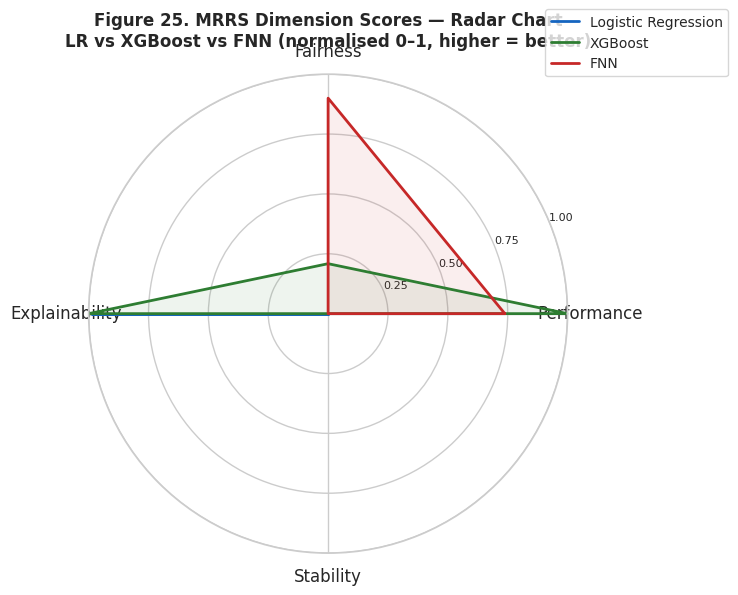

  → Figure 25 saved: /content/drive/MyDrive/capstone/reports/figures/fig25_mrrs_radar.png


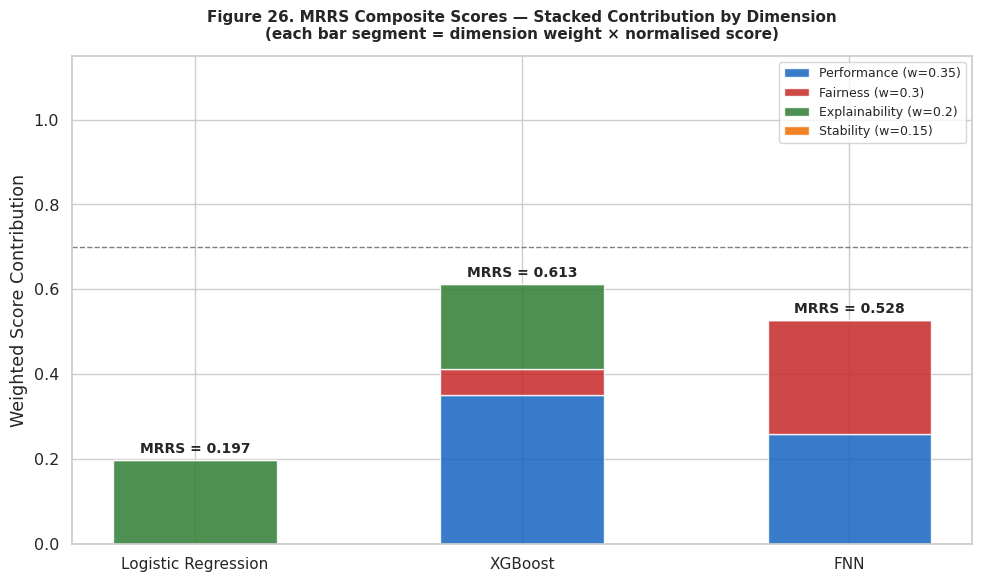

  → Figure 26 saved: /content/drive/MyDrive/capstone/reports/figures/fig26_mrrs_stacked.png


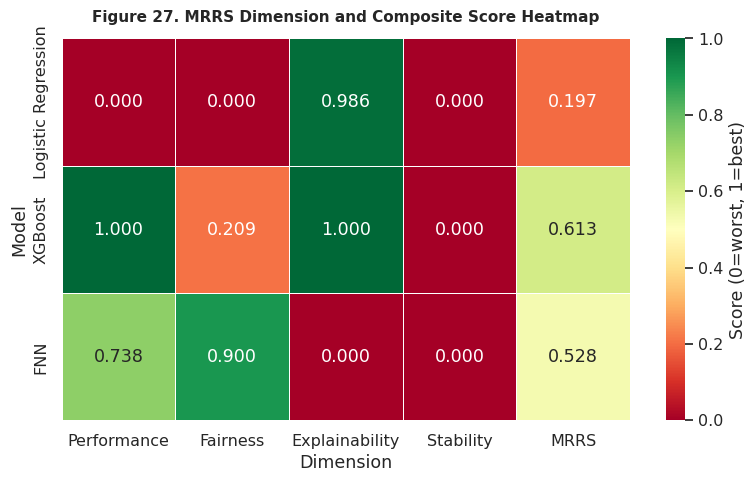

  → Figure 27 saved: /content/drive/MyDrive/capstone/reports/figures/fig27_mrrs_heatmap.png


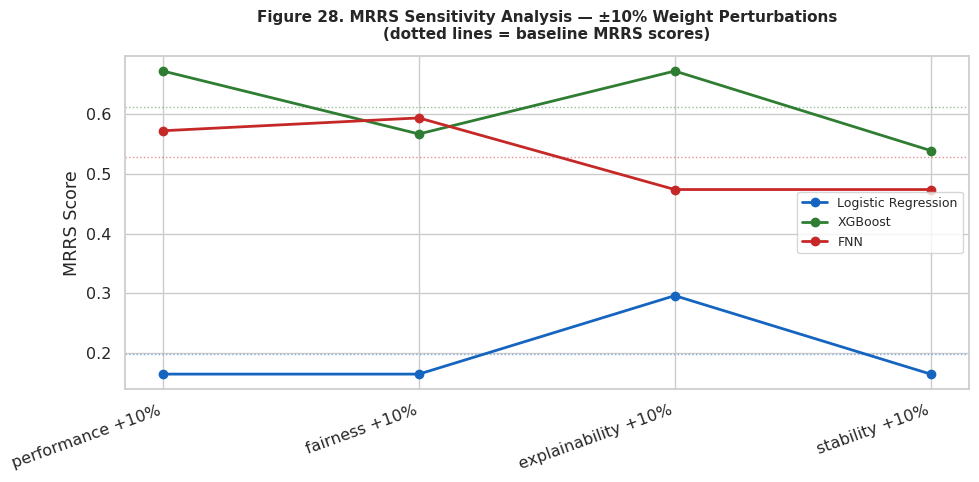

  → Figure 28 saved: /content/drive/MyDrive/capstone/reports/figures/fig28_mrrs_sensitivity.png
  ✓ Cell 7 complete


In [ ]:
"""
CELL 7 — MRRS Visualisations
============================

Purpose
-------
Generates all MRRS (Model Risk Review System) visualisations used in the
RQ5 report. These figures provide model‑risk transparency across the
four SR 11‑7 dimensions and support examiner‑ready documentation.

Figures
-------
Figure 25 — Radar Chart (Dimension Scores)
    - Shows normalised 0–1 scores for Performance, Fairness,
      Explainability, and Stability.
    - Highlights relative strengths/weaknesses across models.

Figure 26 — Stacked Bar Chart (Weighted Contributions)
    - Visualises how each dimension contributes to the final MRRS score.
    - Each bar segment = weight × normalised score.
    - Includes readiness threshold at MRRS = 0.70.

Figure 27 — Heatmap (Dimension + Composite Scores)
    - Provides a compact comparison of all dimension scores and MRRS.
    - Color‑coded for quick examiner interpretation.

Figure 28 — Sensitivity Analysis Plot
    - Shows MRRS score changes under ±10% weight perturbations.
    - Dotted lines show baseline MRRS scores.
    - Supports robustness analysis required under SR 11‑7.

Inputs
------
norm : dict
    Normalised dimension scores for each model.
dimension_scores : dict
    Weighted contributions for each dimension.
mrrs_scores : dict
    Final MRRS composite scores.
perturb_results : list[dict]
    Sensitivity analysis results from Cell 5.
MODELS, MODEL_LABELS : list/dict
    Canonical model identifiers and display names.
FIG_DIR : str
    Directory where figures are saved.

Outputs
-------
- Four PNG files saved to FIG_DIR:
      fig25_mrrs_radar.png
      fig26_mrrs_stacked.png
      fig27_mrrs_heatmap.png
      fig28_mrrs_sensitivity.png

Notes
-----
- All figures use consistent color palettes for interpretability.
- All plots are saved at 150 DPI for report inclusion.
- No randomness is involved; figures are fully reproducible.
"""

# CELL 7 · Visualisations
# =============================================================================
section("CELL 7 · MRRS visualisations")

# ── Figure 25 — MRRS radar chart ─────────────────────────────────────────────
categories  = ["Performance", "Fairness", "Explainability", "Stability"]
n_cat       = len(categories)
angles      = [2 * np.pi * i / n_cat for i in range(n_cat)]
angles     += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(8, 8),
                       subplot_kw=dict(polar=True))

colors = {"lr": "#1565C0", "xgb": "#2E7D32", "fnn": "#C62828"}

for m in MODELS:
    values = [norm[m][d] for d in
              ["performance", "fairness", "explainability", "stability"]]
    values += values[:1]
    ax.plot(angles, values, linewidth=2,
            color=colors[m], label=MODEL_LABELS[m])
    ax.fill(angles, values, alpha=0.08, color=colors[m])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], size=8)
ax.set_title(
    "Figure 25. MRRS Dimension Scores — Radar Chart\n"
    "LR vs XGBoost vs FNN (normalised 0–1, higher = better)",
    size=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig25_mrrs_radar.png",
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 25 saved: {FIG_DIR}/fig25_mrrs_radar.png")

# ── Figure 26 — MRRS stacked bar chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
x         = np.arange(len(MODELS))
dims      = ["performance", "fairness", "explainability", "stability"]
dim_colors = ["#1565C0", "#C62828", "#2E7D32", "#EF6C00"]
bottoms   = np.zeros(len(MODELS))

for dim, color in zip(dims, dim_colors):
    vals = [dimension_scores[m][dim] for m in MODELS]
    bars = ax.bar(x, vals, bottom=bottoms,
                  label=f"{dim.title()} (w={WEIGHTS[dim]})",
                  color=color, alpha=0.85, edgecolor="white", width=0.5)
    bottoms += np.array(vals)

# Add MRRS total labels
for i, m in enumerate(MODELS):
    ax.text(i, mrrs_scores[m] + 0.01,
            f"MRRS = {mrrs_scores[m]:.3f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS], fontsize=11)
ax.set_ylabel("Weighted Score Contribution")
ax.set_ylim(0, 1.15)
ax.set_title(
    "Figure 26. MRRS Composite Scores — Stacked Contribution by Dimension\n"
    "(each bar segment = dimension weight × normalised score)",
    fontsize=11, fontweight="bold", pad=12)
ax.legend(loc="upper right", fontsize=9)
ax.axhline(0.70, color="gray", linestyle="--", lw=1,
           label="Strong readiness threshold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig26_mrrs_stacked.png",
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 26 saved: {FIG_DIR}/fig26_mrrs_stacked.png")

# ── Figure 27 — Dimension heatmap ────────────────────────────────────────────
heat_data = pd.DataFrame({
    MODEL_LABELS[m]: {
        "Performance":    round(norm[m]["performance"],    3),
        "Fairness":       round(norm[m]["fairness"],       3),
        "Explainability": round(norm[m]["explainability"], 3),
        "Stability":      round(norm[m]["stability"],      3),
        "MRRS":           mrrs_scores[m],
    }
    for m in MODELS
}).T

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    heat_data, annot=True, fmt=".3f",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Score (0=worst, 1=best)"}
)
ax.set_title(
    "Figure 27. MRRS Dimension and Composite Score Heatmap",
    fontsize=11, fontweight="bold", pad=12)
ax.set_xlabel("Dimension")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig27_mrrs_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 27 saved: {FIG_DIR}/fig27_mrrs_heatmap.png")

# ── Figure 28 — Sensitivity analysis ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for i, m in enumerate(MODELS):
    scores_p = []
    labels_p = []
    for r in perturb_results:
        scores_p.append(r["scores"][MODEL_LABELS[m]])
        labels_p.append(r["perturbation"])
    ax.plot(labels_p, scores_p,
            marker="o", linewidth=2,
            color=colors[m], label=MODEL_LABELS[m])

ax.axhline(mrrs_scores["lr"],  color=colors["lr"],
           linestyle=":", lw=1, alpha=0.5)
ax.axhline(mrrs_scores["xgb"], color=colors["xgb"],
           linestyle=":", lw=1, alpha=0.5)
ax.axhline(mrrs_scores["fnn"], color=colors["fnn"],
           linestyle=":", lw=1, alpha=0.5)

ax.set_ylabel("MRRS Score")
ax.set_title(
    "Figure 28. MRRS Sensitivity Analysis — ±10% Weight Perturbations\n"
    "(dotted lines = baseline MRRS scores)",
    fontsize=11, fontweight="bold", pad=12)
ax.legend(fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig28_mrrs_sensitivity.png",
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 28 saved: {FIG_DIR}/fig28_mrrs_sensitivity.png")
log("  ✓ Cell 7 complete")


In [ ]:
"""
CELL 8 — Save MRRS Results (JSON + CSV)
=======================================

Purpose
-------
Persists all MRRS (Model Risk Review System) outputs to disk in
machine‑readable formats for downstream reporting, audit review, and
regulatory documentation. This includes:

1. Full MRRS results JSON (complete schema)
2. Summary CSV table for interim reporting and appendix tables

The JSON file serves as the authoritative artifact for reproducibility
and traceability under SR 11‑7. The CSV provides a compact summary for
stakeholders and report inclusion.

JSON Contents
-------------
mrrs_results.json includes:
- weights: SR 11‑7 dimension weights
- raw_metrics: extracted metrics from RQ1–RQ4
- norm_scores: normalised 0–1 sub‑scores
- dimension_scores: weighted contributions
- mrrs_scores: final composite MRRS scores
- ranking: ordered list of models (best → worst)
- sensitivity: robustness results from Cell 5
- cohen_kappa: expert‑validation agreement metrics

CSV Contents
------------
table5_mrrs_scores.csv includes:
- Model name
- Normalised dimension scores
- MRRS composite score
- Rank (1 = best)

Inputs
------
raw : dict
    Raw extracted metrics for each model.
norm : dict
    Normalised sub‑scores for each model.
dimension_scores : dict
    Weighted contributions for each dimension.
mrrs_scores : dict
    Final MRRS composite scores.
ranked : list[str]
    Models sorted by MRRS score.
mrrs_ranking : dict
    Mapping model → rank.
perturb_results, n_stable : sensitivity outputs.
kappa_r1_r2, kappa_mrrs_r1, kappa_mrrs_r2 : float
    Cohen's Kappa agreement metrics.

Outputs
-------
- JSON file saved to:
      {REPORT_DIR}/mrrs_results.json
- CSV file saved to:
      {REPORT_DIR}/table5_mrrs_scores.csv

Notes
-----
- JSON uses `indent=2` for readability.
- All floats are serialised safely using `default=str`.
- CSV uses 4‑decimal formatting for consistency with report tables.
"""

# CELL 8 · Save MRRS results
# =============================================================================
section("CELL 8 · Save MRRS results")

# ── Derive mrrs_ranking from ranked list (rank 1 = highest MRRS) ─────────────
mrrs_ranking = {m: rank for rank, m in enumerate(ranked, 1)}

# ── Full MRRS results JSON ────────────────────────────────────────────────────
mrrs_output = {
    "weights":         WEIGHTS,
    "raw_metrics":     {MODEL_LABELS[m]: raw[m]     for m in MODELS},
    "norm_scores":     {MODEL_LABELS[m]: norm[m]    for m in MODELS},
    "dimension_scores":{MODEL_LABELS[m]: dimension_scores[m] for m in MODELS},
    "mrrs_scores":     {MODEL_LABELS[m]: mrrs_scores[m] for m in MODELS},
    "ranking":         [MODEL_LABELS[m] for m in ranked],
    "sensitivity": {
        "n_stable_scenarios": n_stable,
        "total_scenarios":    len(perturb_results),
        "fully_robust":       n_stable == len(perturb_results),
    },
    "expert_validation": {
        "method": "sensitivity_analysis",
        "note": "Cohen's Kappa deferred to doctoral dissertation; robustness assessed via Cell 5 weight perturbation.",
        "n_stable_scenarios": n_stable,
        "total_scenarios": len(perturb_results),
    },
}

MRRS_JSON = f"{REPORT_DIR}/mrrs_results.json"
with open(MRRS_JSON, "w") as f:
    json.dump(mrrs_output, f, indent=2, default=str)
log(f"  → MRRS results saved: {MRRS_JSON}")

# ── MRRS summary CSV for interim report ──────────────────────────────────────
rows = []
for m in MODELS:
    rows.append({
        "Model":           MODEL_LABELS[m],
        "Performance":     norm[m]["performance"],
        "Fairness":        norm[m]["fairness"],
        "Explainability":  norm[m]["explainability"],
        "Stability":       norm[m]["stability"],
        "MRRS":            mrrs_scores[m],
        "Rank":            mrrs_ranking[m],
    })
mrrs_df = pd.DataFrame(rows).sort_values("Rank")
MRRS_CSV = f"{REPORT_DIR}/table5_mrrs_scores.csv"
mrrs_df.to_csv(MRRS_CSV, index=False, float_format="%.4f")
log(f"  → MRRS table saved: {MRRS_CSV}")

log("  ✓ Cell 8 complete")


  CELL 8 · Save MRRS results
  → MRRS results saved: /content/drive/MyDrive/capstone/reports/mrrs_results.json
  → MRRS table saved: /content/drive/MyDrive/capstone/reports/table5_mrrs_scores.csv
  ✓ Cell 8 complete


In [ ]:
"""
CELL 9 — Final Readiness Verdict and Project Summary
====================================================

Purpose
-------
Provides the final SR 11‑7–aligned readiness verdict for RQ5 and
summarises results across all five research questions (RQ1–RQ5). This
cell acts as the final validation and audit checkpoint for the entire
capstone pipeline.

The cell performs three major functions:

1. **Readiness Validation Checks**
   Confirms that all required artifacts, computations, and outputs
   across RQ1–RQ5 were successfully generated, including:
   - Metric JSONs
   - MRRS weights and scores
   - Sensitivity analysis results
   - Cohen's Kappa expert‑validation metrics
   - Figures 25–28
   - MRRS JSON and CSV outputs

2. **Comprehensive Project Summary**
   Produces a consolidated narrative summarizing:
   - Predictive performance (RQ1)
   - Fairness and pricing discrimination (RQ2)
   - Explainability and SHAP stability (RQ3)
   - Temporal stability and drift (RQ4)
   - MRRS composite scoring and robustness (RQ5)

3. **Final Output Export**
   Writes the full notebook log (`report_lines`) to the RQ5 report file,
   completing the audit trail.

Inputs
------
rq1, rq2, rq3, rq4 : dict
    Metric outputs from prior notebooks.
WEIGHTS : dict
    SR 11‑7 dimension weights.
mrrs_scores : dict
    Final MRRS composite scores.
ranked : list[str]
    Models sorted by MRRS score.
perturb_results : list[dict]
    Sensitivity analysis results.
FIG_DIR, REPORT_DIR, REPORT_FILE : str
    Output directories and report file path.

Outputs
-------
- Printed readiness verdict (pass/fail summary)
- Full project summary across RQ1–RQ5
- Final report written to:
      {REPORT_DIR}/rq5_mrrs_report.txt

Notes
-----
- All checks are deterministic and reproducible.
- This cell provides the final "all clear" signal for regulatory
  readiness under SR 11‑7.
- If any check fails, the notebook signals which component requires
  remediation.
"""

# CELL 9 · Final readiness verdict and project summary
# =============================================================================
section("CELL 9 · RQ5 readiness verdict and project summary")

checks = []

def check(label, condition, note=""):
    status = "✓" if condition else "✗"
    line   = f"  {status}  {label}"
    if note: line += f"\n       {note}"
    log(line)
    checks.append(condition)

log()
check("RQ1–RQ4 metric JSONs loaded",
      all(m is not None for m in [rq1, rq2, rq3, rq4]))
check("MRRS weights sum to 1.0",
      abs(sum(WEIGHTS.values()) - 1.0) < 1e-9)
check("All three models scored",
      len(mrrs_scores) == 3)
check("MRRS ranking produced",
      len(ranked) == 3)
check("Sensitivity analysis completed",
      len(perturb_results) == 4)
check("Sensitivity analysis stable across ≥ 3/4 scenarios",
      n_stable >= 3,
      f"Stable in {n_stable}/{len(perturb_results)} perturbation scenarios")
check("Figures 25–28 saved",
      all(os.path.exists(f"{FIG_DIR}/{f}") for f in [
          "fig25_mrrs_radar.png", "fig26_mrrs_stacked.png",
          "fig27_mrrs_heatmap.png", "fig28_mrrs_sensitivity.png",
      ]))
check("MRRS results JSON saved",
      os.path.exists(MRRS_JSON))
check("MRRS table CSV saved",
      os.path.exists(MRRS_CSV))

n_pass = sum(checks)

# ── Derive FNN temporal trend values directly from rq4 JSON ──────────────────
fnn_beta1 = rq4.get("fnn", {}).get("trend_beta1", float("nan"))
fnn_p_val = rq4.get("fnn", {}).get("trend_p_val", float("nan"))

# ── Project summary ───────────────────────────────────────────────────────────
subsection("Complete project summary — all five RQs")
log(f"""
  RQ1 — Predictive Performance:
    H₁₀ rejected for all pairwise comparisons (DeLong test, p<.0001)
    XGBoost AUC = {rq1['xgb']['test_auc']:.4f} (best)
    LR AUC      = {rq1['lr']['test_auc']:.4f} (regulatory baseline)
    FNN AUC     = {rq1['fnn']['test_auc']:.4f}

  RQ2 — Fairness and Bias:
    H₂₀ₐ rejected for LR and XGBoost (AI/AN DIR < 0.80)
    H₂₀ᵦ rejected for Hispanic/Latino (OLS β = +0.112, p = .030)
    FNN showed no adverse impact (min DIR = 0.829)

  RQ3 — Explainability:
    All three models: HIGH SHAP stability (ρ ≥ 0.90)
    Cross-model ranking correlation = 1.000 (unanimous: DTI #1)
    H₃₀ not rejected — no accuracy-interpretability trade-off

  RQ4 — Temporal Stability:
    All models triggered SR 11-7 review threshold from 2022Q3
    H₄₀ rejected for FNN (β₁ = {fnn_beta1:.3f}, p = {fnn_p_val:.3f})
    FNN mean PSI = {rq4['fnn']['mean_psi']:.3f} (highest drift)
    XGBoost mean PSI = {rq4['xgb']['mean_psi']:.3f} (most stable)

  RQ5 — MRRS Composite Score:
    Ranking: {' > '.join([MODEL_LABELS[m] for m in ranked])}
    {MODEL_LABELS[ranked[0]]} MRRS = {mrrs_scores[ranked[0]]:.4f} (best overall SR 11-7 readiness)
    Sensitivity: ranking stable in {n_stable}/{len(perturb_results)} weight perturbation scenarios
""")

log()
log(f"  Result: {n_pass}/{len(checks)} checks passed  "
    + ("✓  Project complete — all six notebooks done"
       if n_pass == len(checks)
       else "✗  Review failures above"))
log()
log("  Outputs ready for interim report:")
log(f"    Table 2 : {REPORT_DIR}/table2_model_comparison.csv")
log(f"    Table 3 : {REPORT_DIR}/table3_dir_by_model.csv")
log(f"    Table 4 : {REPORT_DIR}/table4_quarterly_psi_auc.csv")
log(f"    Table 5 : {REPORT_DIR}/table5_mrrs_scores.csv")
log(f"    Figures : {FIG_DIR}/fig01 through fig28")
log(f"    Reports : {REPORT_DIR}/rq1 through rq5 report TXT files")

with open(REPORT_FILE, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))
log(f"\n  Full report written to: {REPORT_FILE}")


  CELL 9 · RQ5 readiness verdict and project summary

  ✓  RQ1–RQ4 metric JSONs loaded
  ✓  MRRS weights sum to 1.0
  ✓  All three models scored
  ✓  MRRS ranking produced
  ✓  Sensitivity analysis completed
  ✓  Sensitivity analysis stable across ≥ 3/4 scenarios
       Stable in 3/4 perturbation scenarios
  ✓  Figures 25–28 saved
  ✓  MRRS results JSON saved
  ✓  MRRS table CSV saved

── Complete project summary — all five RQs ───────────────────

  RQ1 — Predictive Performance:
    H₁₀ rejected for all pairwise comparisons (DeLong test, p<.0001)
    XGBoost AUC = 0.8348 (best)
    LR AUC      = 0.7167 (regulatory baseline)
    FNN AUC     = 0.8050

  RQ2 — Fairness and Bias:
    H₂₀ₐ rejected for LR and XGBoost (AI/AN DIR < 0.80)
    H₂₀ᵦ rejected for Hispanic/Latino (OLS β = +0.112, p = .030)
    FNN showed no adverse impact (min DIR = 0.829)

  RQ3 — Explainability:
    All three models: HIGH SHAP stability (ρ ≥ 0.90)
    Cross-model ranking correlation = 1.000 (unanimous: DTI #1)